# Predicción de Churn en Telco — 05 · Evaluación final e interpretación

**Única evaluación sobre el test** (20%, 1.409 clientes, nunca usado en el desarrollo):
estima el rendimiento esperado del modelo final en producción. Incluye la traducción a
términos operativos (curva de ganancia), la calidad de las probabilidades (calibración)
y la interpretación del modelo (SHAP) — material de apoyo para la presentación.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42

def cargar_datos():
    """Carga y limpieza minima definida en 01_eda.ipynb."""
    df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
    X = df.drop(columns=["customerID", "Churn"])
    y = (df["Churn"] == "Yes").astype(int)
    ids = df["customerID"]
    return X, y, ids

def particion(X, y, ids):
    """Misma particion estratificada 80/20 usada en 02_experimentos.ipynb."""
    return train_test_split(X, y, ids, test_size=0.20, stratify=y, random_state=SEED)

In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             precision_score, recall_score, fbeta_score,
                             confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

X, y, ids = cargar_datos()
X_train, X_test, y_train, y_test, ids_train, ids_test = particion(X, y, ids)
modelo = joblib.load("modelo_final.joblib")
with open("umbral_operativo.json") as f:
    umbral = json.load(f)["umbral"]

score_test = modelo.predict_proba(X_test)[:, 1]
pred_test = (score_test >= umbral).astype(int)

pr_auc_test = average_precision_score(y_test, score_test)
print(f"PR-AUC test:    {pr_auc_test:.4f}  (CV train: 0.672 | baseline azar: {y_test.mean():.3f})")
print(f"Precision test: {precision_score(y_test, pred_test):.4f}")
print(f"Recall test:    {recall_score(y_test, pred_test):.4f}")
print(f"F2 test:        {fbeta_score(y_test, pred_test, beta=2):.4f}")
print(f"Contactados:    {pred_test.mean():.1%} de la cartera")

PR-AUC test:    0.6655  (CV train: 0.672 | baseline azar: 0.265)
Precision test: 0.4527
Recall test:    0.8957
F2 test:        0.7491
Contactados:    52.5% de la cartera


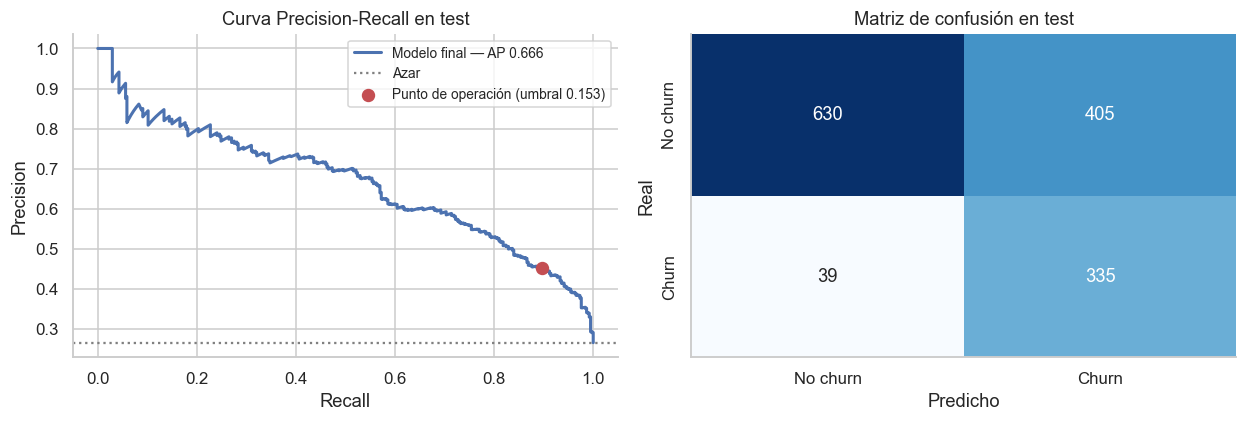

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

prec, rec, _ = precision_recall_curve(y_test, score_test)
axes[0].plot(rec, prec, color="#4C72B0", lw=2,
             label=f"Modelo final — AP {pr_auc_test:.3f}")
axes[0].axhline(y_test.mean(), color="gray", ls=":", label="Azar")
axes[0].scatter([recall_score(y_test, pred_test)],
                [precision_score(y_test, pred_test)],
                color="#C44E52", zorder=5, s=60,
                label=f"Punto de operación (umbral {umbral:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall en test")
axes[0].legend(fontsize=9)

cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"])
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de confusión en test")
sns.despine()
plt.tight_layout()
plt.show()

## Curva de ganancia: ¿qué pasa si el equipo de retención tiene menos capacidad?

El umbral operativo (F2) implica accionar sobre ~52% de la cartera. Si la capacidad es
menor, el mismo score permite priorizar: la curva muestra qué porcentaje de los churners
se captura contactando al top-X% de clientes ordenados por riesgo.

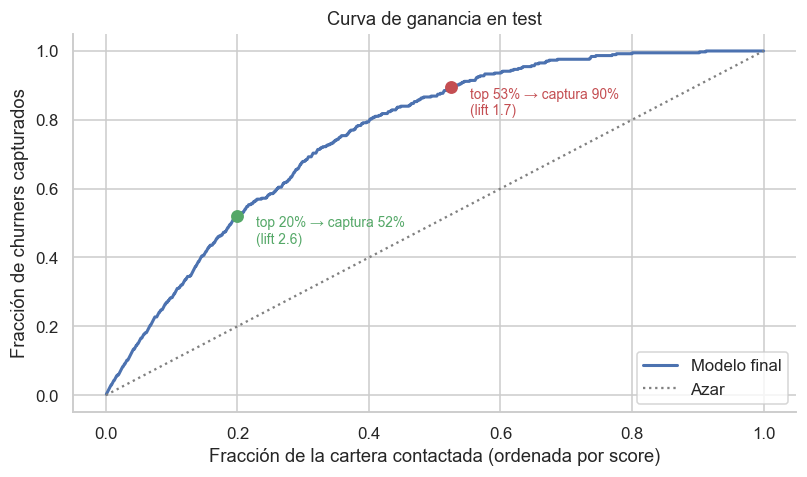

top 10%: captura 28.3% de los churners (lift 2.83)
top 20%: captura 52.1% de los churners (lift 2.61)
top 30%: captura 67.9% de los churners (lift 2.26)
top 40%: captura 79.4% de los churners (lift 1.99)


In [4]:
orden = np.argsort(-score_test)
y_ordenado = y_test.values[orden]
frac = np.arange(1, len(y_ordenado) + 1) / len(y_ordenado)
ganancia = np.cumsum(y_ordenado) / y_ordenado.sum()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(frac, ganancia, color="#4C72B0", lw=2, label="Modelo final")
ax.plot([0, 1], [0, 1], color="gray", ls=":", label="Azar")
for p, colr in [(0.20, "#55A868"), (float(pred_test.mean()), "#C44E52")]:
    k = int(p * len(y_ordenado))
    ax.scatter([p], [ganancia[k - 1]], color=colr, zorder=5, s=55)
    ax.annotate(f"top {p:.0%} → captura {ganancia[k-1]:.0%}\n(lift {ganancia[k-1]/p:.1f})",
                (p, ganancia[k - 1]), textcoords="offset points", xytext=(12, -18),
                fontsize=9, color=colr)
ax.set_xlabel("Fracción de la cartera contactada (ordenada por score)")
ax.set_ylabel("Fracción de churners capturados")
ax.set_title("Curva de ganancia en test")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

for p in [0.10, 0.20, 0.30, 0.40]:
    k = int(p * len(y_ordenado))
    print(f"top {p:.0%}: captura {ganancia[k-1]:.1%} de los churners (lift {ganancia[k-1]/p:.2f})")

## Calibración: ¿los scores son probabilidades reales?

Para usar el score como probabilidad (por ejemplo, en un cálculo de valor esperado
de una campaña) tiene que estar calibrado: de los clientes con score 0,3, ~30% deberían
churnear efectivamente.

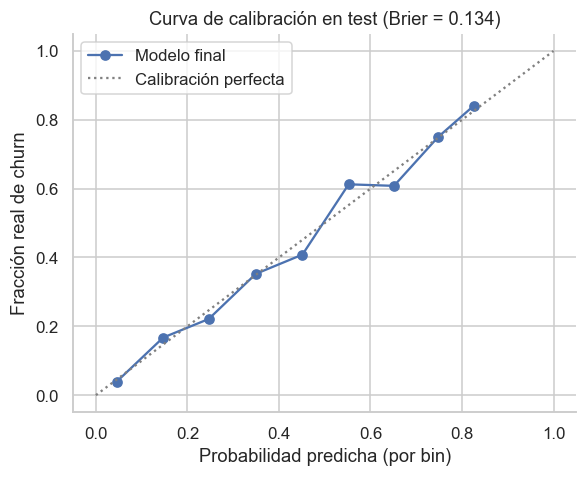

In [5]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_real, prob_pred = calibration_curve(y_test, score_test, n_bins=10)
brier = brier_score_loss(y_test, score_test)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(prob_pred, frac_real, "o-", color="#4C72B0", label="Modelo final")
ax.plot([0, 1], [0, 1], color="gray", ls=":", label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha (por bin)")
ax.set_ylabel("Fracción real de churn")
ax.set_title(f"Curva de calibración en test (Brier = {brier:.3f})")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

El modelo está **bien calibrado de fábrica** (puntos sobre la diagonal;
Brier 0,134 vs 0,195 de un predictor no informativo): los scores se pueden leer
directamente como probabilidades de churn, sin necesidad de recalibración.

## Interpretación del modelo (SHAP)

Valores SHAP sobre el test: cuánto empuja cada feature el score de cada cliente,
hacia churn (positivo) o permanencia (negativo).

C:\Users\ftamaki\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\ftamaki\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


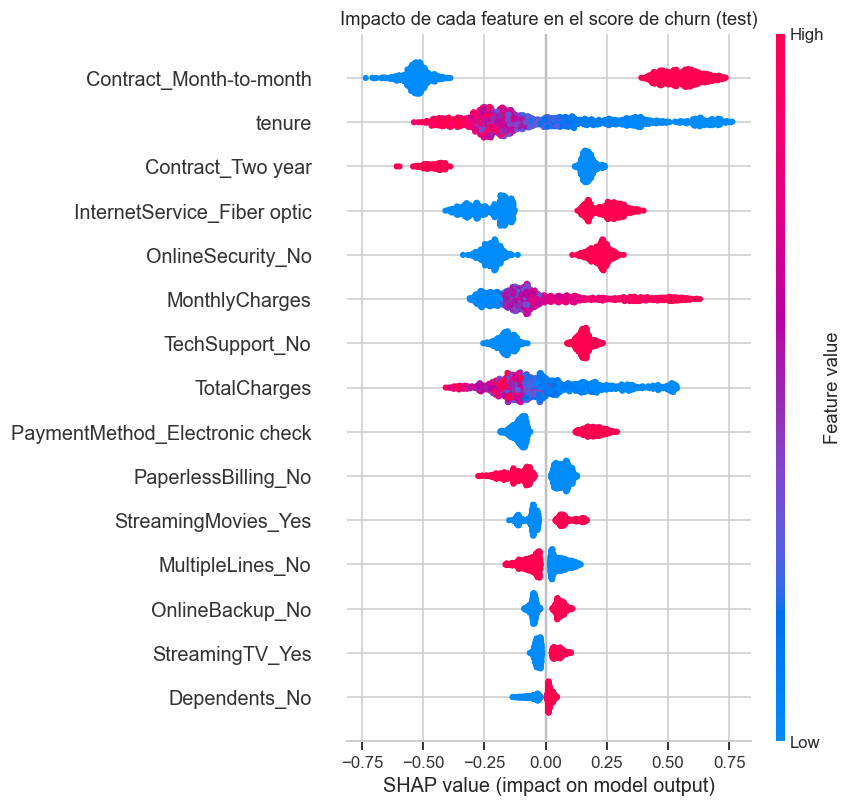

In [6]:
import shap

prep = modelo.named_steps["prep"]
clf = modelo.named_steps["clf"]
X_test_t = prep.transform(X_test)
nombres = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]

explainer = shap.TreeExplainer(clf)
shap_vals = explainer.shap_values(X_test_t)
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

shap.summary_plot(shap_vals, X_test_t, feature_names=nombres,
                  max_display=15, show=False)
plt.title("Impacto de cada feature en el score de churn (test)")
plt.tight_layout()
plt.show()

## Lectura final

**Rendimiento en test (única evaluación):**

| Métrica | Test | Estimado en CV (train) |
|---|---|---|
| PR-AUC | **0,666** | 0,672 |
| Recall | **89,6%** | 90,1% |
| Precision | **45,3%** | 44,9% |
| F2 | **0,749** | 0,750 |

- El test confirma casi exactamente lo estimado por validación cruzada: **la metodología fue
  honesta** (sin fuga de información ni sobreajuste de selección). Este es el rendimiento
  esperable en producción sobre clientes nuevos.
- **Traducción operativa:** en el punto de operación (umbral 0,153) se contacta al ~52% de
  la cartera y se intercepta al ~90% de los churners. Con menos capacidad, la curva de
  ganancia muestra el menú: con el **top 20% se captura el 52%** de los churners (lift 2,6),
  con el top 10% el 28% (lift 2,8). El umbral es una decisión de negocio; el modelo entrega
  el ranking.
- **Scores calibrados:** pueden usarse como probabilidades reales, lo que habilita decidir
  el corte por valor esperado (probabilidad × valor del cliente × efectividad de la oferta −
  costo) cuando se disponga de esos parámetros.
- **SHAP coincide con el EDA:** el contrato mes a mes es por lejos el driver principal
  (impacto medio 0,54, el doble que el segundo), seguido por la antigüedad, el contrato de
  2 años (protector), la fibra óptica, la falta de `OnlineSecurity`/`TechSupport`, los cargos
  mensuales y el pago con cheque electrónico. El modelo aprendió los patrones que el
  análisis exploratorio anticipaba — coherencia que da confianza y simplifica la narrativa.